In [1]:
%load_ext autoreload
%autoreload 2

# python
import os
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
hep.style.use("ATLAS")
# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    "font.size": 12               # default font size
})

# import pandas as pd
import math
import sys
sys.path.append("../")
import socket
import glob
import json
import itertools

# custom
import Utils as ut
aleph = ut.loadALEPH2004Result(hepData = "/home/badea/e+e-/aleph/UnfoldThrustResults/HEPData-ins636645-v1-Table_54.csv")

THRUST,THRUST LOW,THRUST HIGH,(1/SIG)*D(SIG)/DTHRUST,stat +,stat -,sys_1 +,sys_1 -,sys_2 +,sys_2 -


/home/badea/e+e-/aleph/unfold-ee-logtau/Plotting/Utils.py:161: RuntimeWarning: divide by zero encountered in log
  aleph_log_bins = np.log(aleph_bins)


In [2]:
# plotOutDir = "ibuResult"
plotOutDir = "neutralsCheck"
os.makedirs(plotOutDir, exist_ok=True)

In [3]:
# top_dir = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-065e8543" # niter = 4
# top_dir = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-825bab2d" # niter = 4, with bootstrap mc and data
# top_dir = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-340d639a" # niter=4, complete ucyoung processing, new neutrals variation
# top_dir = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-ea076078" # niter=4, complete ucyoung processing, new neutrals variation
# top_dir = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-48721328" # with ner_in and ner_out, 30% nes variation applied to both data and mc
top_dir = "/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-f8528cb9" # with ner 2.5%, nes 5% to mc only

filePath = os.path.join(top_dir, "*/conf.json")
fileList = sorted(glob.glob(filePath))
print(len(fileList))

17


In [4]:
def loadWeightPaths(fileList):
    
    d = {}

    for file_path in fileList:
        with open(file_path) as f:
            conf = json.load(f)

        job_type = conf["job_type"]
        var_key = conf["reco"].split("_thrust_")[-1].split("_t.root")[0]
        niter = conf["niter"]
        weight_path = os.path.dirname(file_path)
            
        if job_type not in d:
            d[job_type] = {}

        key2 = niter if job_type == "NiterScan" else var_key
        if key2 not in d[job_type]:
            d[job_type][key2] = []

        # weight indices to use
        nominal_idx = 2 # 2 IBU iterations
        niter_syst_idx = 3 # NITER systematic for 3 iterations
        if job_type == "NiterScan":
            nominal_idx = -1 # just pick up the last one
            
        # load weight
        ibu_phis = np.load(os.path.join(weight_path, "ibu_phis.npy")) # last one is the final iteration
        print(job_type, key2, ibu_phis.shape)
        corr = np.load(os.path.join(weight_path, "hadronic_event_sel_corr.npy")) # hadronic event selection
        d[job_type][key2] = ibu_phis[nominal_idx] * corr
        
        # load stat uncertainty
        if job_type == "Nominal":

            d["BootstrapMC"] = {}
            d["BootstrapMC"]["nominal"] = np.load(os.path.join(weight_path, "ibu_phi_bootstrap_mc.npy"))

            d["BootstrapData"] = {}
            d["BootstrapData"]["nominal"] = np.load(os.path.join(weight_path, "ibu_phi_bootstrap_data.npy"))

            # bins
            d["Nominal"]["bins"] = np.load(os.path.join(weight_path, "bins.npy"))

            # niter=3 
            if "Systematics" not in d.keys():
                d["Systematics"] = {}
            d["Systematics"]["niter"] = ibu_phis[niter_syst_idx] * corr

        # if closure test print the directory
        if job_type == "ClosureTest":
            d[job_type] = {}
            d[job_type]["nominal"] = np.load(os.path.join(weight_path, "ibu_phis.npy"))[-1]
            d[job_type]["reco"] = np.load(os.path.join(weight_path, "data_hist.npy"))
            d[job_type]["gen"] = np.load(os.path.join(weight_path, "gen_hist.npy"))
            
    return d

w = loadWeightPaths(fileList)
for key, val in w.items():
    for k, v in val.items():
        print(key, k, v.shape)

NiterScan 2 (3, 42)
Systematics ech10 (5, 42)
NiterScan 3 (4, 42)
TheoryUncertainty_Sherpa nominal (5, 42)
TheoryUncertainty_Herwig nominal (5, 42)
ClosureTest nominal (5, 42)
Systematics nes_down (5, 42)
TheoryUncertainty_Pythia8 nominal (5, 42)
Systematics no_neutrals (5, 42)
NiterScan 4 (5, 42)
NiterScan 1 (2, 42)
Systematics nes_up (5, 42)
Systematics ner (5, 42)
Systematics ntpc7 (5, 42)
Nominal nominal (5, 42)
Systematics with_met (5, 42)
Systematics pt04 (5, 42)
NiterScan 2 (42,)
NiterScan 3 (42,)
NiterScan 4 (42,)
NiterScan 1 (42,)
Systematics ech10 (42,)
Systematics nes_down (42,)
Systematics no_neutrals (42,)
Systematics nes_up (42,)
Systematics ner (42,)
Systematics ntpc7 (42,)
Systematics niter (42,)
Systematics with_met (42,)
Systematics pt04 (42,)
TheoryUncertainty_Sherpa nominal (42,)
TheoryUncertainty_Herwig nominal (42,)
ClosureTest nominal (42,)
ClosureTest reco (42,)
ClosureTest gen (42,)
TheoryUncertainty_Pythia8 nominal (42,)
Nominal nominal (42,)
Nominal bins (43,

In [5]:
# bins and centers
bins = w["Nominal"]["bins"]
x = (bins[:-1] + bins[1:]) / 2

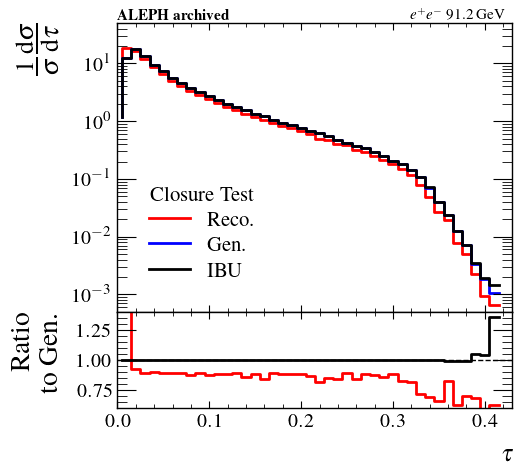

In [6]:
# closure check
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},  # top panel taller, bottom three equal
    figsize=[5,5]
)
plt.subplots_adjust(hspace=0)

# hists
axs[0].step(x, w["ClosureTest"]["reco"], label="Reco.", color="red")
axs[0].step(x, w["ClosureTest"]["gen"], label="Gen.", color="blue")
axs[0].step(x, w["ClosureTest"]["nominal"], label="IBU", color="black")

# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)
axs[0].text(0.74, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)

# labels
axs[0].set_ylabel(r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$", fontsize=25)
axs[0].set_yscale("log")
axs[0].set_ylim(5*10**-4, 5*10**1)

# ratios
axs[1].step(x, w["ClosureTest"]["reco"]/w["ClosureTest"]["gen"], color="red")
axs[1].step(x, w["ClosureTest"]["nominal"]/w["ClosureTest"]["gen"], color="black")

axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
axs[1].set_ylim(0.6, 1.4)
axs[1].set_xlim(0, 0.43)
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel("Ratio\nto Gen.", fontsize=20)

axs[0].legend(ncol=1, fontsize=15, title="Closure Test", title_fontsize=15)

plt.show()

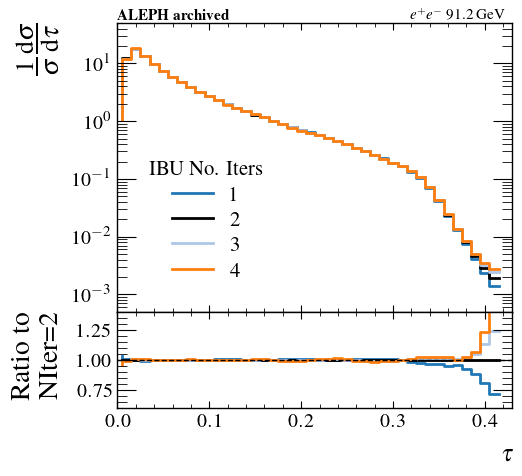

In [7]:
# closure check
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]},  # top panel taller, bottom three equal
    figsize=[5,5]
)
plt.subplots_adjust(hspace=0)

# hists
colors = plt.cm.tab20.colors  # 20 unique colors
color_cycle = itertools.cycle(colors)
for i in range(1,5):
    c = "black" if i == 2 else next(color_cycle) 
    axs[0].step(x, w["NiterScan"][i], color=c, label=i)
    axs[1].step(x, w["NiterScan"][i]/w["NiterScan"][2], color=c)

# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)
axs[0].text(0.74, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)

# labels
axs[0].set_ylabel(r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$", fontsize=25)
axs[0].set_yscale("log")
axs[0].set_ylim(5*10**-4, 5*10**1)


axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
axs[1].set_ylim(0.6, 1.4)
axs[1].set_xlim(0, 0.43)
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel("Ratio to\nNIter=2", fontsize=20)

axs[0].legend(ncol=1, fontsize=15, title="IBU No. Iters", title_fontsize=15)

plt.show()

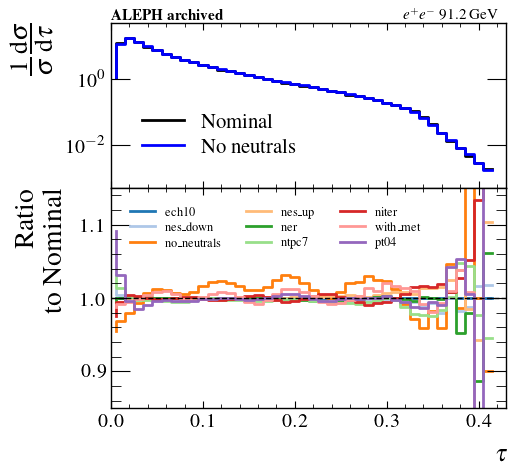

In [8]:
# closure check
fig, axs = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [1.5, 2]},  # top panel taller, bottom three equal
    figsize=[5,5]
)
plt.subplots_adjust(hspace=0)

# hists
axs[0].step(x, w["Nominal"]["nominal"], label="Nominal", color="black")
axs[0].step(x, w["Systematics"]["no_neutrals"], label="No neutrals", color="blue")

# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)
axs[0].text(0.74, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=11)

# labels
axs[0].set_ylabel(r"$\frac{{1}}{{\sigma}} \frac{{\mathrm{d}\sigma}}{{\mathrm{d}\tau}}$", fontsize=25)
axs[0].set_yscale("log")
axs[0].set_ylim(5*10**-4, 5*10**1)

# ratios
# axs[1].step(x, w["Systematics"]["no_neutrals"]/w["Nominal"]["nominal"], color="blue", label="No Neutrals")
# axs[1].step(x, w["Systematics"]["pt04"]/w["Nominal"]["nominal"], color="red", label="Pt04")
# axs[1].step(x, w["Systematics"]["with_met"]/w["Nominal"]["nominal"], color="green", label="with_met")


colors = plt.cm.tab20.colors  # 20 unique colors
color_cycle = itertools.cycle(colors)
for k in w["Systematics"].keys():
    axs[1].step(x, w["Systematics"][k]/w["Nominal"]["nominal"], color=next(color_cycle), label=k)
    
axs[1].axhline(y=1, color='black', linestyle='--', alpha=1, lw=1)
axs[1].set_ylim(0.85, 1.15)
axs[1].set_xlim(0, 0.43)
axs[1].set_xlabel(r"$\tau$")
axs[1].set_ylabel("Ratio\nto Nominal", fontsize=20)

axs[0].legend(ncol=1, fontsize=15, title="", title_fontsize=15)
axs[1].legend(ncol=3, fontsize=9, title="", title_fontsize=9)

plt.show()

In [9]:
# statistical uncertainty
total_stat = np.sqrt(
    w["BootstrapMC"]["nominal"]**2 +
    w["BootstrapData"]["nominal"]**2
)

In [10]:
# flags for experimental systematics
skipNoNeutrals = True

# experimental systematic 
exp_syst_names = []
exp_syst = []
nes = {}

for key, val in w["Systematics"].items():
    
    # skip no neutrals
    if skipNoNeutrals and key in ["no_neutrals"]:
        print(f"Skipping {key}")
        continue

    # max value for nes_up and nes_down
    if key in ["nes_up", "nes_down"]:
        print("Handling NES:", key)
        nes[key] = np.abs(w["Nominal"]["nominal"] - val)
        continue
                        
    # compute  
    # if key == "nes_up":
    #     nes_up = np.abs(w["Nominal"]["nominal"] - val)
    #     nes_down = np.abs(w["Nominal"]["nominal"] - w["Systematics"]["nes_down"])
    #     nes = np.maximum(nes_up, nes_down)
    #     exp_syst.append(nes)
    #     exp_syst_names.append("nes")
    # elif key == "nes_down":
    #     continue
    # else:
    exp_syst.append(w["Nominal"]["nominal"] - val)
    exp_syst_names.append(key)

# do nes
nes = np.maximum(nes["nes_up"], nes["nes_down"])
exp_syst.append(nes)
exp_syst_names.append("nes")

print(exp_syst_names)
exp_syst = np.stack(exp_syst)
print(exp_syst.shape)
total_exp_syst = np.sqrt(np.sum(exp_syst**2, axis=0))
print(total_exp_syst.shape)

Handling NES: nes_down
Skipping no_neutrals
Handling NES: nes_up
['ech10', 'ner', 'ntpc7', 'niter', 'with_met', 'pt04', 'nes']
(7, 42)
(42,)


In [11]:
# theoretical uncertainty
th_syst_names = ["Pythia8", "Herwig", "Sherpa"]
th_syst = []
for key in th_syst_names:
    th_syst.append(w["Nominal"]["nominal"] - w[f"TheoryUncertainty_{key}"]["nominal"])
th_syst = np.stack(th_syst)
print(th_syst.shape)
# total_th_syst = np.sqrt(np.sum(th_syst**2, axis=0))
total_th_syst = np.max(np.abs(th_syst), axis=0)
print(total_th_syst.shape)

(3, 42)
(42,)


In [12]:
total_uncert = np.sqrt(
    total_stat**2 + 
    total_exp_syst**2 + 
    total_th_syst **2
)
print(total_uncert.shape)

(42,)


Reminder since divide by nominal we don't need to scale by hadronic event selection.


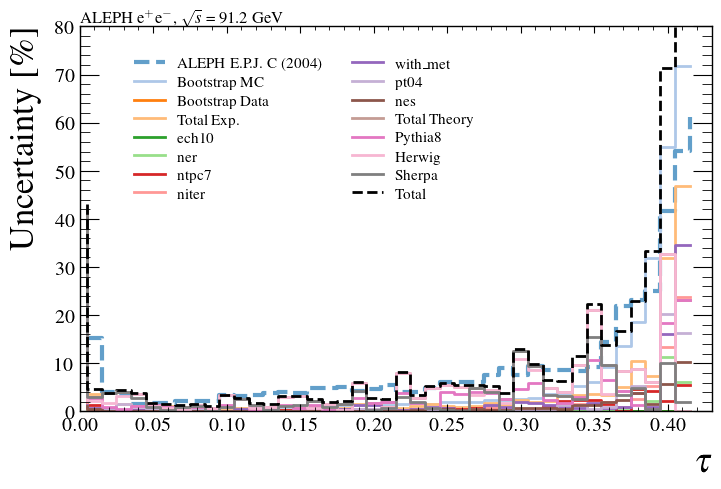

In [13]:
print("Reminder since divide by nominal we don't need to scale by hadronic event selection.")

# plot uncertainty breakdown
fig, ax = plt.subplots(figsize=(8, 5))
# Use a color cycle from matplotlib that doesn't repeat for the number of error components
colors = plt.cm.tab20.colors  # 20 unique colors
color_cycle = itertools.cycle(colors)

# draw aleph
ax.step(aleph["aleph_midbins"], aleph["aleph_thrust_errs"] / aleph["aleph_thrust"] * 100, where='post', label="ALEPH E.P.J. C (2004)", color=next(color_cycle), linestyle="--", lw=3, alpha=0.7)

# draw MC stat
ax.step(x, w["BootstrapMC"]["nominal"]/w["Nominal"]["nominal"]*100, label="Bootstrap MC", color=next(color_cycle))
ax.step(x, w["BootstrapData"]["nominal"]/w["Nominal"]["nominal"]*100, label="Bootstrap Data", color=next(color_cycle))

# draw experimental
ax.step(x, total_exp_syst/w["Nominal"]["nominal"]*100, label="Total Exp.", color=next(color_cycle))
for name, unc in zip(exp_syst_names, exp_syst):
    ax.step(x, np.abs(unc)/w["Nominal"]["nominal"]*100, label=name, color=next(color_cycle))
    
# draw theory
ax.step(x, total_th_syst/w["Nominal"]["nominal"]*100, label="Total Theory", color=next(color_cycle))
for name, unc in zip(th_syst_names, th_syst):
    ax.step(x, np.abs(unc)/w["Nominal"]["nominal"]*100, label=name, color=next(color_cycle))
    
# draw total
ax.step(x, total_uncert/w["Nominal"]["nominal"]*100, label="Total", color="Black", ls="--")

ax.text(0, 1, r"ALEPH e$^{+}$e$^{-}$, $\sqrt{s}$ = 91.2 GeV", transform=ax.transAxes, ha='left', va='bottom', fontsize=12)

ax.set_ylim(0, 80)
# ax.set_yscale("log")
# ax.set_ylim(5*10**-3, 2*10**3)
ax.set_xlim(0, 0.43)
ax.set_ylabel(r"Uncertainty [$\%$]", fontsize=25)
ax.set_xlabel(r"$\tau$", fontsize=25)

ax.legend(ncol=2, fontsize=11, bbox_to_anchor=(0.05, 0.98), loc="upper left")

plt.show()

In [14]:
outFileName = os.path.join(top_dir, "ibu_results.npz")
print(outFileName)
np.savez(
    outFileName,
    # nominal result
    nominal = w["Nominal"]["nominal"],
    # statistical uncertainty components
    total_stat = total_stat,
    bootstrapmc = w["BootstrapMC"]["nominal"],
    bootstrapdata = w["BootstrapData"]["nominal"],
    # experimental systematic
    exp_syst_names = exp_syst_names,
    exp_syst = exp_syst,
    total_exp_syst = total_exp_syst,
    # theory uncertainty from MC prior
    th_syst_names = th_syst_names,
    th_syst = th_syst,
    total_th_syst = total_th_syst,
    # total error from quadrature sum of mcstat, total exp syst, total theory syst
    total_uncert = total_uncert,
)

/home/badea/e+e-/aleph/unfold-ee-logtau/ibu_results/training-f8528cb9/ibu_results.npz


In [15]:
d = {}
with np.load(outFileName) as data:
    for k in data.keys():
        v = data[k]
        # If it's an object array whose first element is a str, treat it as a text list
        if v.dtype == object and len(v) > 0 and isinstance(v[0], str):
            print(f"{k}: text list -> {v.tolist()}")
        else:
            print(f"{k}: numpy array, shape {v.shape}, dtype {v.dtype}")
        # store 
        d[k] = v

nominal: numpy array, shape (42,), dtype float64
total_stat: numpy array, shape (42,), dtype float64
bootstrapmc: numpy array, shape (42,), dtype float64
bootstrapdata: numpy array, shape (42,), dtype float64
exp_syst_names: numpy array, shape (7,), dtype <U8
exp_syst: numpy array, shape (7, 42), dtype float64
total_exp_syst: numpy array, shape (42,), dtype float64
th_syst_names: numpy array, shape (3,), dtype <U7
th_syst: numpy array, shape (3, 42), dtype float64
total_th_syst: numpy array, shape (42,), dtype float64
total_uncert: numpy array, shape (42,), dtype float64


3 niter
2 ntpc7
5 pt04
0 ech10
4 with_met
1 ner
6 nes


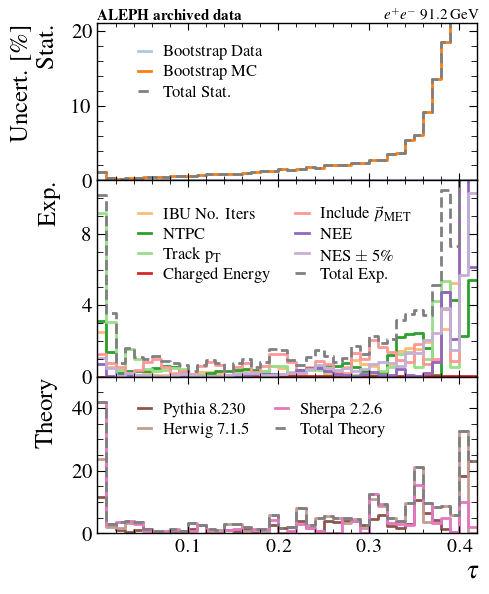

In [37]:
import itertools

def extend_y(temp):
    return np.append(temp, temp[-1])
    
# Enable LaTeX text rendering
plt.rcParams.update({
    "text.usetex": True,          # use LaTeX for all text
    "font.family": "serif",       # optional: use serif font
    "font.size": 12               # default font size
})

# global style
style = {
    "legend_loc" : None,
    "legend_bbox" : None,
    "legend_ncol" : 1,
    "legend_fontsize" : 13,
    "ax1_ylabel_fs" : 22,
    "ax2_xlabel_fs" : 18,
    "ax2_ylabel_fs" : 16,
    "ax1_tick_ls" : 16,
    "ax2_tick_ls" : 16,
    "figsize" : (5,6), 
    "header_fontsize" : 11,
    "ax1_xlim" : [0, 0.42],
    "ax1_ylim" : [2*10**-3, 7*10**-1],
    "ax1_ylabel" : "Uncertainty [$\%$]",
    "ax1_xlabel" : r"$\tau$",
    "legend_bbox" : (0.45, 0.05),  
}

# labels for individual components
statLabels = {
    "bootstrapdata" : "Bootstrap Data",
    "bootstrapmc" : "Bootstrap MC"
}
expLabels = {
    "ntpc7" : "NTPC",
    "pt04": r"Track p$_{\mathrm{T}}$",
    "ech10" : "Charged Energy",
    "no_neutrals" : "Nuetrals Excluded",
    "with_met" : r"Include $\vec{p}_{\mathrm{MET}}$",
    "niter" : "IBU No. Iters",
    "nes": "NES $\pm$ 5\%",
    # "nes_down": "NES Down 5\%",
    "ner": "NEE",
}
theoryLabels = {
    "Pythia8" : "Pythia 8.230",
    "Herwig" : "Herwig 7.1.5", 
    "Sherpa" : "Sherpa 2.2.6",
}

fontsize = 18
legendfontsize = 12

colors = plt.cm.tab20.colors  # 20 unique colors
color_cycle = itertools.cycle(colors)  # restartable iterator

# plotting
fig, axs = plt.subplots(
    3, 1,
    sharex=True,
    gridspec_kw={'height_ratios': [1,1.25,1]},  # top panel taller, bottom three equal
    figsize=style["figsize"]
)
plt.subplots_adjust(hspace=0)


# header
axs[0].text(0, 1.0, r"$\textbf{ALEPH\ archived\ data}$", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])
axs[0].text(0.755, 1.0, r"$e^{+}e^{-}$ 91.2 GeV", transform=axs[0].transAxes, ha='left', va='bottom', fontsize=style["header_fontsize"])

next(color_cycle)

# statistical
ax = axs[0]
ax.set_ylim(0, 21)
stat_oder = ["bootstrapdata", "bootstrapmc"]
for i, label in enumerate(stat_oder):
    ax.step(bins, extend_y(np.abs(d[label])/d["nominal"]*100), where='post', label=statLabels[label], color=next(color_cycle), ls="-")
ax.step(bins, extend_y(d["total_stat"]/d["nominal"]*100), where='post', label="Total Stat.", color="gray", ls="--")

ax.legend(
    ncol=1, 
    fontsize=legendfontsize, 
    bbox_to_anchor=(0.04, 0.35), 
    loc="lower left",
    handletextpad=0.7,
    handlelength=0.8, 
    columnspacing=0.6
)

# experimental
ax = axs[1]
ax.set_ylim(0, 11)
# ax.set_yticks([0,2,4,6,8,10])
ax.set_yticks([0,4,8])
# exp_order = ['niter', 'ntpc7', 'pt04', 'ech10', "no_neutrals", 'with_met']
exp_order = ['niter', 'ntpc7', 'pt04', 'ech10', "no_neutrals", 'with_met', 'ner', 'nes']
# exp_order = ["no_neutrals", 'nes_up', 'nes_down', 'ner']

if skipNoNeutrals:
    exp_order = [i for i in exp_order if i != "no_neutrals"]
    
for label in exp_order:
    i = [i for i, l in enumerate(d["exp_syst_names"]) if l == label][0]
    print(i, label)
    ax.step(bins, extend_y(np.abs(d["exp_syst"][i])/d["nominal"]*100), where='post', label=expLabels[label], color=next(color_cycle), ls="-")
ax.step(bins, extend_y(d["total_exp_syst"]/d["nominal"]*100), where='post', label="Total Exp.", color="gray", ls="--")
ax.legend(
    ncol=2, 
    fontsize=legendfontsize, 
    bbox_to_anchor=(0.04, 0.35), 
    loc="lower left",
    handletextpad=0.7,
    handlelength=0.8, 
    columnspacing=1.5
)

# theory
ax = axs[2]
ax.set_ylim(0, 50)
ax.set_yticks([0,20,40])
for i, label in enumerate(d["th_syst_names"]):
    ax.step(bins, extend_y(np.abs(d["th_syst"][i])/d["nominal"]*100), where='post', label=theoryLabels[label], color=next(color_cycle), ls="-")
ax.step(bins, extend_y(d["total_th_syst"]/d["nominal"]*100), where='post', label="Total Theory", color="gray", ls="--")
ax.legend(
    ncol=2, 
    fontsize=legendfontsize,  
    bbox_to_anchor=(0.04, 0.45), 
    loc="lower left",
    handletextpad=0.7,
    handlelength=0.8, 
    columnspacing=1.5
)


axs[0].set_xlim(style["ax1_xlim"][0], style["ax1_xlim"][1])
axs[0].set_xticks([0.1,0.2,0.3,0.4])

# ax1 settings
for ax, name in zip(axs, ["Uncert. [$\%$]\nStat.", "Exp.", "Theory"]): # "MC Prior"
    if name == "Exp.":
        ax.set_ylabel(name, fontsize=18, labelpad=16)
    else:
        ax.set_ylabel(name, fontsize=18)
    
# set final x-axis
axs[-1].set_xlabel(style["ax1_xlabel"], fontsize=style.get("ax2_xlabel_fs", 18), labelpad=4)
    
# tick length
for ax in axs:
    ax.tick_params(axis="y", which="major", length=6)
    ax.tick_params(axis="y", which="minor", length=4)
    ax.tick_params(axis="x", which="major", length=5)
    ax.tick_params(axis="x", which="minor", length=3)

# tick size
# axs[0].tick_params(axis='y', labelsize=16)
for ax in axs:
    ax.tick_params(axis='y', labelsize=15)
    


fig.set_size_inches(style["figsize"][0], style["figsize"][1])  
fig.subplots_adjust(left=0.18, right=0.94, top=0.95, bottom=0.1)

outFileName = f"{plotOutDir}/tau_ibu_aleph_uncertainty.pdf"
if skipNoNeutrals:
        outFileName = outFileName.replace(".pdf", "_NEENES.pdf")
plt.savefig(outFileName, bbox_inches=None, dpi=150)

# from PyPDF2 import PdfReader, PdfWriter, Transformation
ut.watermark(
    outFileName, # input file name
    outFileName.replace(".pdf", "_eea.pdf"), # output file name
    # scale=0.045, tx=200, ty=365,
    scale=0.045, tx=200, ty=360,
    logo_fpath='./ee-logo.pdf',
)

ut.watermark(
    outFileName, # input file name
    outFileName.replace(".pdf", "_eea_transparent.pdf"), # output file name
    scale=0.045, tx=200, ty=365,
    logo_fpath='./ee-logo-transparent.pdf',
)

plt.show()
plt.close()